# **Exploratory Data Analysis**
# Dataset: Churn Cleaned Dataset (BigML)

  This dataset contains telecom customer data with 2666 rows and 20 columns, including customer usage patterns, account information and whether the customer churned or not.

**Objective:**
1) Calculate summary statistics(mean, median,mode,standard deviation)
2) Visualize data distribution using histogram, boxplots, and scatter plots.
3) Find correlation between numerical features.

**Tools Used**
- Python 3
- Pandas - for data manipulation and analysis.
- Matplotlib - for base ploting functionality
- Seaborn - for statistical visualization build on top of matplotlib.

**Findings**


* The distributions of Total day minutes, Total evening minutes, and Total
night minutes were all approximately bell-shaped, suggesting these features are normally distributed across customers.

* Boxplots of international usage revealed that Total intl calls contained the most visible outliers, indicating that a small number of customers made significantly more international calls than the majority.
* The scatter plot of Total intl minutes vs Total intl charge showed a clear, strong positive linear relationship, confirming that international charges increase directly and proportionally with usage minutes.
* The correlation heatmap revealed strong positive correlations between usage minutes and their corresponding charges across all time periods. This pattern reflects the per-minute billing structure of the telecom provider.
* Notable negative correlations were observed between churn and number of voicemail messages, and between churn and total international calls. This suggests that customers who engage more with voicemail features and international calling may be less likely to leave the service.





I began by importing pandas for data manipulation and analysis

In [1]:
# Import pandas for data loading and manipulation
import pandas as pd

I loaded the cleaned dataset produced in Task 1 directly from Google Drive

In [2]:
# Load the cleaned churn dataset from Google Drive into panda DataFrame
df = pd.read_csv('/content/drive/MyDrive/churn_cleaned (1).csv')

Before analysing the data, I inspected its structure to confirm column names, data types, and whether any null values remain after cleaning.

In [3]:
# Display dataset structure: column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [4]:
# Display the full DataFrame to visually inspect the data
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,201.028909,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,201.028909,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,201.028909,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,201.028909,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,201.028909,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.400000,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.100000,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.300000,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.900000,91,8.64,14.1,6,3.81,2,False


Summary statistics give a numerical overview of the dataset.

In [5]:
# Generate descriptive statistics for all numerical columns
# Includes count, mean, std, min, max, and quartile values
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.414273,100.310203,30.512404,200.386159,100.023631,17.033072,201.121687,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.118412,19.988162,9.215733,50.951515,20.161445,4.330864,50.684124,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.500000,87.000000,24.380000,165.300000,87.000000,14.050000,167.100000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.550092,101.000000,30.590000,200.900000,100.000000,17.080000,201.028909,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.750000,114.000000,36.700000,235.100000,114.000000,19.980000,236.275000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.800000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


 I separatedly calculate mean, median, standard deviation, and mode to understand the central tendency and variability of each feature.

In [6]:
# Calculate the mean (average) of all numerical columns
df.select_dtypes(include='number').mean()

,0
Account length,100.620405
Area code,437.438860
Number vmail messages,8.021755
Total day minutes,179.414273
Total day calls,100.310203
Total day charge,30.512404
Total eve minutes,200.386159
Total eve calls,100.023631
Total eve charge,17.033072
Total night minutes,201.121687


In [7]:
# Calculate the median (middle value)
df.select_dtypes(include='number').median()

,0
Account length,100.000000
Area code,415.000000
Number vmail messages,0.000000
Total day minutes,179.550092
Total day calls,101.000000
Total day charge,30.590000
Total eve minutes,200.900000
Total eve calls,100.000000
Total eve charge,17.080000
Total night minutes,201.028909


In [8]:
# Calculate standard deviation — measures how spread out values are around the mean
df.select_dtypes(include='number').std()

,0
Account length,39.563974
Area code,42.521018
Number vmail messages,13.612277
Total day minutes,54.118412
Total day calls,19.988162
Total day charge,9.215733
Total eve minutes,50.951515
Total eve calls,20.161445
Total eve charge,4.330864
Total night minutes,50.684124


In [9]:
# Calculate the mode — the most frequently occurring value in each column
df.select_dtypes(include='number').mode()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,93.0,415.0,0.0,179.550092,105.0,27.59,169.9,105.0,14.25,201.028909,105.0,9.66,10.0,3.0,2.7,1.0
1,NaN,NaN,NaN,NaN,NaN,31.18,NaN,NaN,16.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Import matplotlib for base plotting functionality
import matplotlib.pyplot as plt

In [11]:
# Import seaborn for statistical visualisations built on top of matplotlib
import seaborn as sns

I used histograms to visualise the distribution of call minutes across different time periods — day, evening, and night.

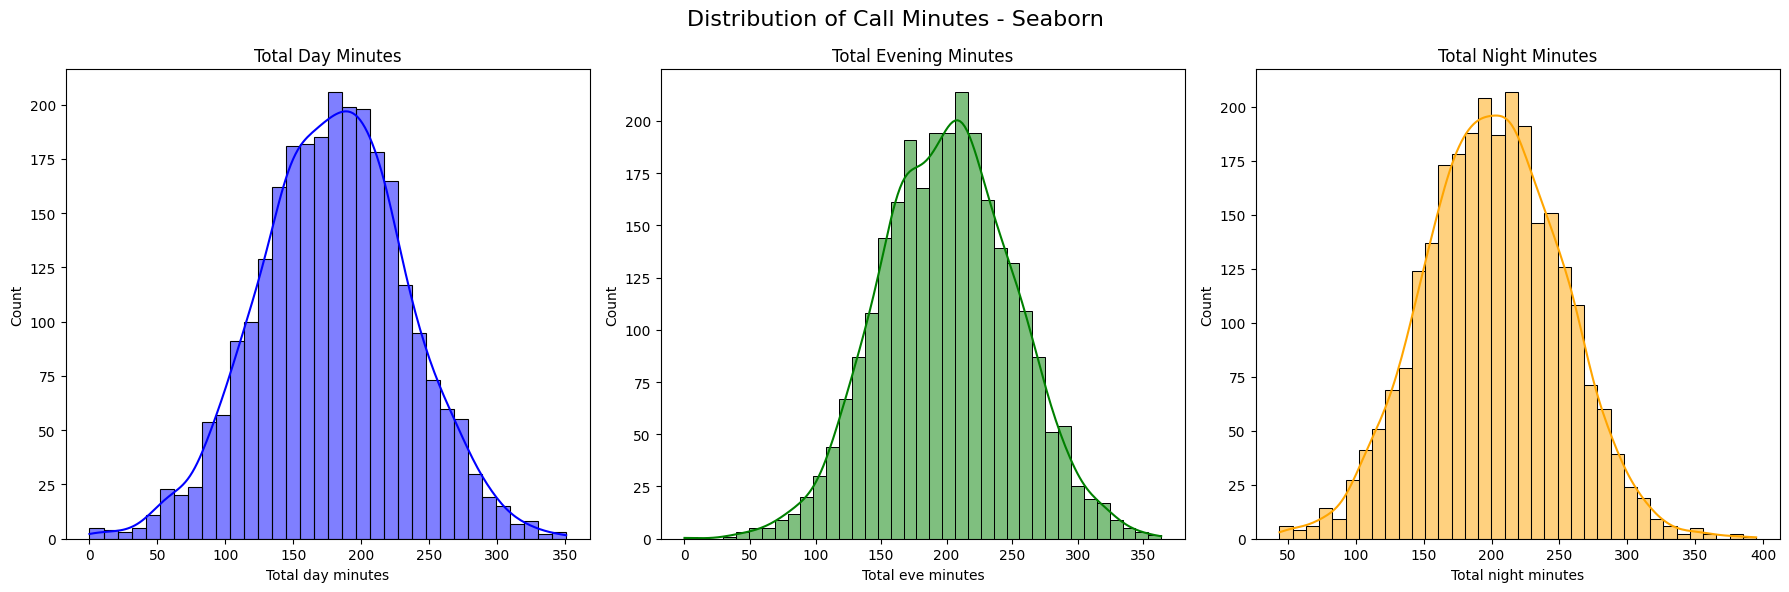

In [13]:
# Create a figure with 3 side-by-side subplots, each 15x5 inches total
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# First histogram
sns.histplot(df['Total day minutes'], color='blue', kde=True, ax=axes[0])
axes[0].set_title('Total Day Minutes')

# Second histogram
sns.histplot(df['Total eve minutes'], color='green', kde=True, ax=axes[1])
axes[1].set_title('Total Evening Minutes')

# Third histogram
sns.histplot(df['Total night minutes'], color='orange', kde=True, ax=axes[2])
axes[2].set_title('Total Night Minutes')

plt.suptitle('Distribution of Call Minutes - Seaborn', fontsize=16)
plt.tight_layout()
plt.show()

Boxplots helped me visualise the spread and identify outliers in the international usage columns.

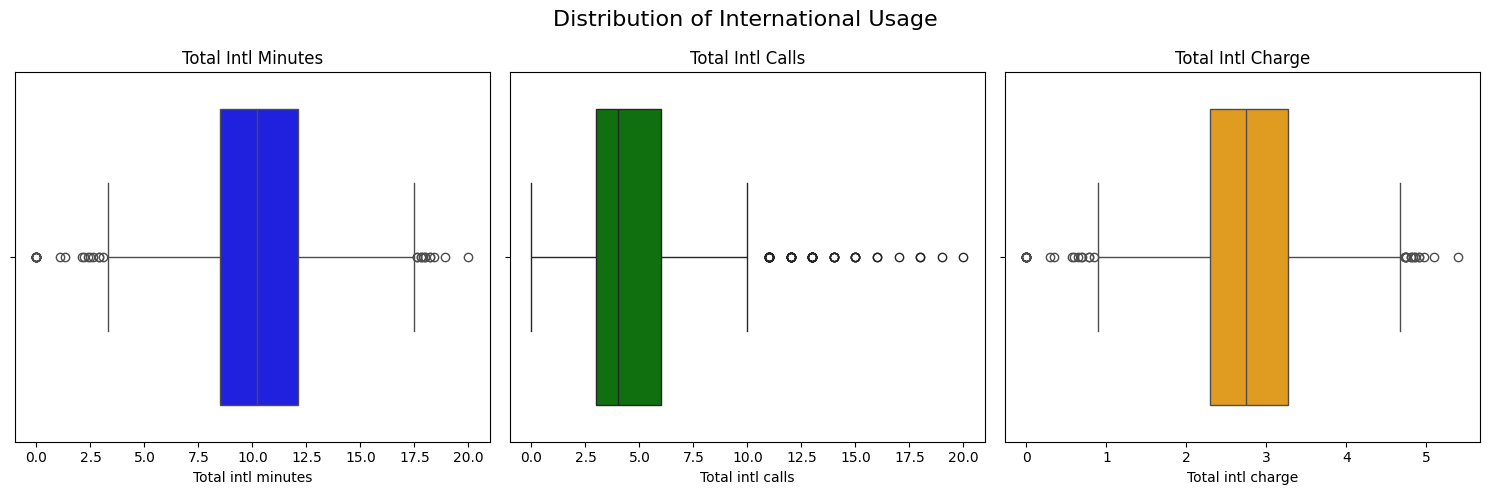

In [14]:
# Create a figure with 3 side-by-side subplots, each 15x5 inches total
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# First Boxplot
sns.boxplot(data=df, x='Total intl minutes', color='blue', ax=axes[0])
axes[0].set_title('Total Intl Minutes')

# Second Boxplot
sns.boxplot(data=df, x='Total intl calls', color='green', ax=axes[1])
axes[1].set_title('Total Intl Calls')

# Third Boxplot
sns.boxplot(data=df, x='Total intl charge', color='orange', ax=axes[2])
axes[2].set_title('Total Intl Charge')

plt.suptitle('Distribution of International Usage', fontsize=16)
plt.tight_layout()
plt.show()

Scatter plot shows the relationship between the number of international minutes a customer use related to the charge they incur.

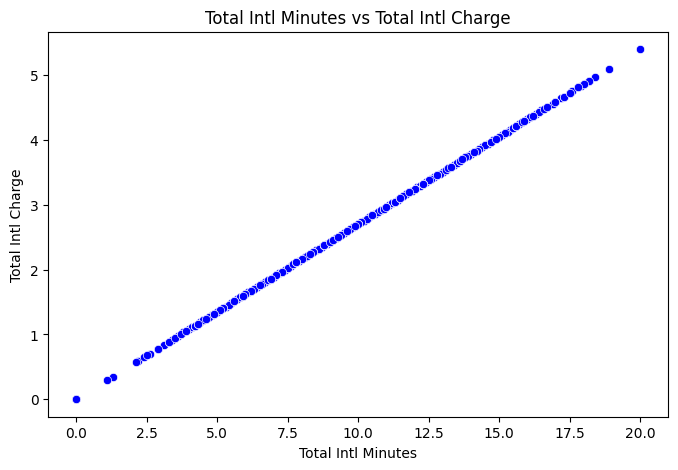

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Total intl minutes', y='Total intl charge', color='blue')
plt.title('Total Intl Minutes vs Total Intl Charge')
plt.xlabel('Total Intl Minutes')
plt.ylabel('Total Intl Charge')
plt.show()

Correlation analysis quantifies the strength and direction of linear relationships between numerical variables.

In [16]:
# --- Correlation Analysis ---

# Step 1: Generate the correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                        Account length  Area code  Number vmail messages  \
Account length                1.000000  -0.008620              -0.002996   
Area code                    -0.008620   1.000000              -0.000584   
Number vmail messages        -0.002996  -0.000584               1.000000   
Total day minutes             0.001388  -0.023202               0.017829   
Total day calls               0.038862  -0.009629              -0.009622   
Total day charge              0.002843  -0.023130               0.019027   
Total eve minutes            -0.015923   0.000679               0.011401   
Total eve calls               0.018552  -0.018602               0.005131   
Total eve charge             -0.015909   0.000707               0.011418   
Total night minutes          -0.009481  -0.003184              -0.003697   
Total night calls            -0.024007   0.011455               0.008124   
Total night charge           -0.008999  -0.003382              -0.000229   
Total intl m

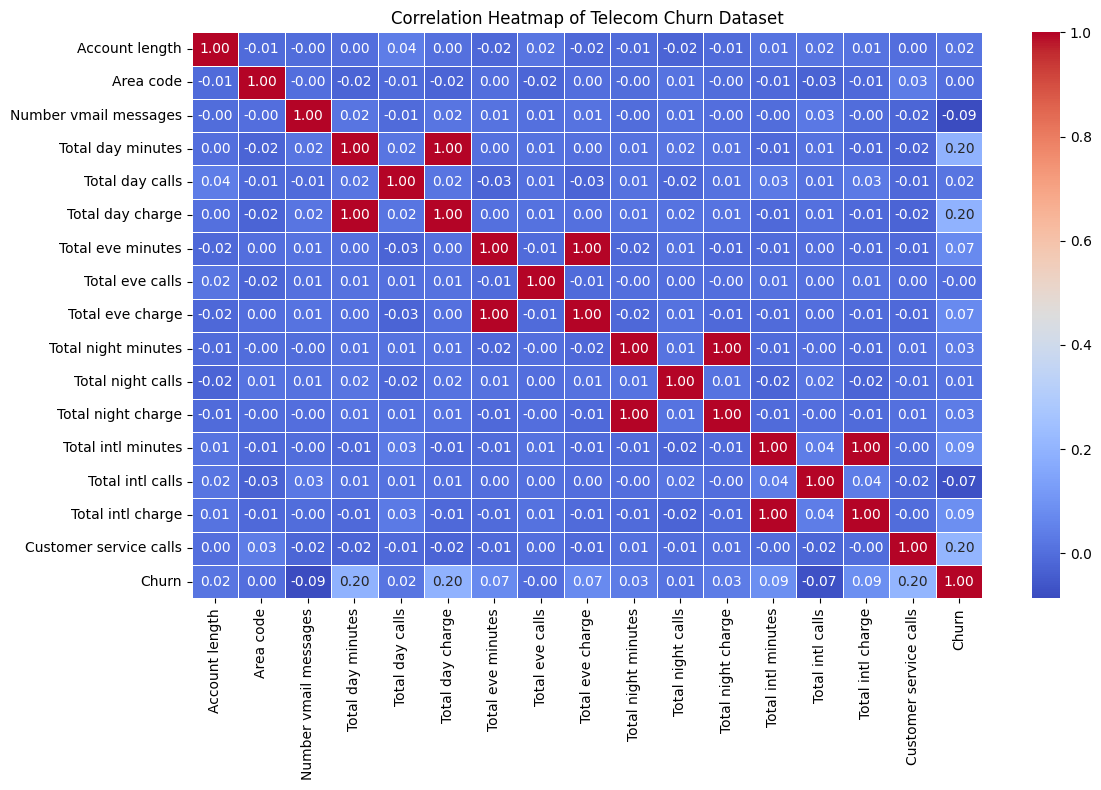

In [17]:
# Step 2: Visualise the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Telecom Churn Dataset")
plt.tight_layout()
plt.show()